## 05-3. 파생변수 만들기

<Axes: xlabel='test'>

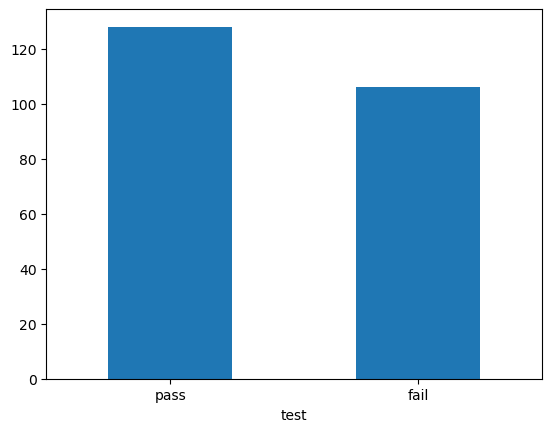

In [ ]:
import pandas as pd
import numpy as np

mpg = pd.read_csv('mpg.csv')
mpg['total'] = (mpg['cty'] + mpg['hwy']) / 2                # 시내+고속 종합연비 파생변수 추가
mpg['test'] = np.where(mpg['total'] >= 20, 'pass','fail')   # 연비합격기준 20
count_test = mpg['test'].value_counts()
count_test.plot.bar(rot=0)

<Axes: xlabel='grade'>

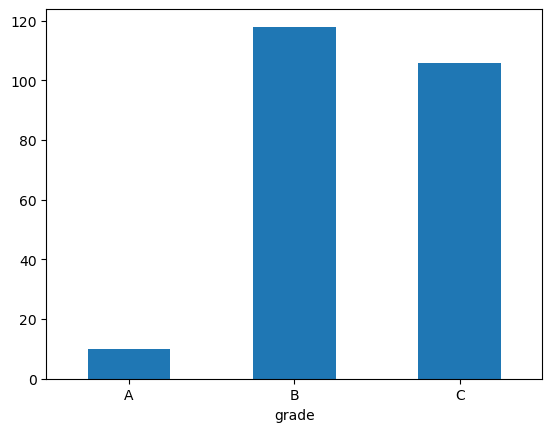

In [ ]:
# 연비등급을 3종류로 만들어본다
mpg['grade'] = np.where(mpg['total'] >= 30, 'A', np.where(mpg['total'] >= 20, 'B','C'))
count_grade = mpg['grade'].value_counts().sort_index()
count_grade.plot.bar(rot=0)

In [ ]:
# 특정조건에 만족하는 파생변수 만들기 2
# compact | subcompact | 2seater 라면 small 아니면 large
mpg['size'] = np.where( (mpg['category'] == 'compact') |(mpg['category'] == 'subcompact') | (mpg['category'] == '2seater'), 'small','large')
mpg['size'].value_counts()

size
large    147
small     87
Name: count, dtype: int64

아시아인구 백분율 평균값 : 0.0049
asian - large town count: 318 , small-town count : 119


<Axes: xlabel='size_asian', ylabel='Frequency'>

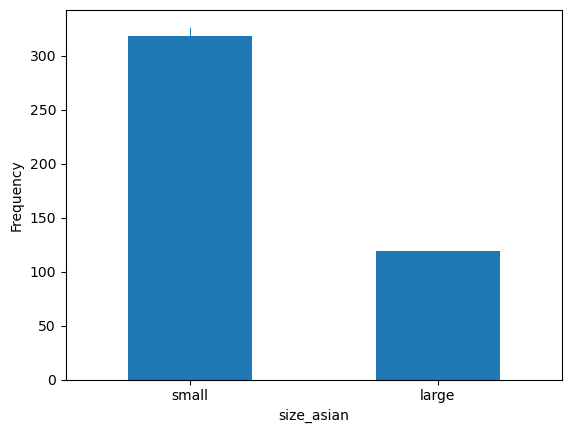

In [ ]:
# 05장 최종연습문제

# Q1
md = pd.read_csv('midwest.csv')
md.info()
md.shape # 437행 28열 

# Q2. 전체인구 poptotal변수를 'total'로 , popasian인구를 asian으로 수정
md = md.rename(columns={'poptotal':'total','popasian':'asian'})

# Q3. total, asian변수를 이용해 전체인구대비 아시아인구 백분율 파생변수를 추가한후 히스토그램을 만들어 분포를 살펴본다
md['percent_asian'] = (md['asian'] / md['total'])
md['percent_asian'].plot.hist()

# Q4. 아시아인구 백분율 전체 평균을 구하고 평균을 초과하면 'large' 그외에는 'small'을 부여하는 새로운 파생변수 만들어본다
asian_mean = md['percent_asian'].mean()
print(f'아시아인구 백분율 평균값 : {asian_mean:.4f}')
md['size_asian'] = np.where(md['percent_asian'] >= asian_mean, 'large','small')

# Q5. large , small 비율이 얼마나 많은지 빈도표와 막대그래프를 만들어본다
asian_ratio = md['size_asian'].value_counts()
print(f'asian - large town count: {asian_ratio.iloc[0]} , small-town count : {asian_ratio.iloc[1]}')
asian_ratio.plot.bar(rot=0)